In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [3]:
df = pd.read_csv("Chocolate_Sales.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   str           
 1   Country        3282 non-null   str           
 2   Product        3282 non-null   str           
 3   Date           3282 non-null   datetime64[us]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 154.0 KB


In [20]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [21]:
df.describe()

,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252285,6030.338775,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


In [ ]:
The dataset contains missing values and some columns are not in the correct data type. Data cleaning is required before analysis.

In [23]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [25]:
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

In [26]:
df.dtypes

Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [ ]:
The Date column was converted to datetime format, and the Amount column was cleaned and converted to numeric type for proper analysis.

In [28]:
# Fill Amount with mean
df['Amount'] = df['Amount'].fillna(df['Amount'].mean())

# Fill Boxes Shipped with median
df['Boxes Shipped'] = df['Boxes Shipped'].fillna(df['Boxes Shipped'].median())

# Fill categorical columns with mode
df['Sales Person'] = df['Sales Person'].fillna(df['Sales Person'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Product'] = df['Product'].fillna(df['Product'].mode()[0])

In [29]:
df.isna().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [ ]:
Missing values were handled using mean for Amount, median for Boxes Shipped, and mode for categorical columns.

In [7]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]
outliers

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
66,Van Tuxwell,Australia,Organic Choco Syrup,2022-08-10,19453.00,14
135,Van Tuxwell,India,Organic Choco Syrup,2022-05-16,19929.00,174
212,Marney O'Breen,UK,Smooth Sliky Salty,2022-05-13,18991.00,88
434,Jan Morforth,New Zealand,Mint Chip Choco,2022-06-30,18340.00,285
543,Ches Bonnell,India,Peanut Butter Cubes,2022-01-27,22050.00,208
589,Curtice Advani,India,Smooth Sliky Salty,2022-04-19,19327.00,135
609,Jan Morforth,Australia,Mint Chip Choco,2022-02-22,17626.00,103
751,Rafaelita Blaksland,New Zealand,Eclairs,2022-02-07,19481.00,51
806,Brien Boise,India,85% Dark Bars,2022-08-09,18032.00,205
1008,Kaine Padly,UK,After Nines,2022-01-21,18697.00,176


In [ ]:
Outliers were detected using the IQR method. Values outside the defined range were considered outliers.

In [8]:
df_clean = df[(df['Amount'] >= lower) & (df['Amount'] <= upper)]
df_clean

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.00,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.00,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.00,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.00,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.00,184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303.58,354
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339.32,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616.09,238
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504.62,397


In [ ]:
Outliers were removed to improve data quality and reduce their impact on analysis.

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_clean[['Amount', 'Boxes Shipped']])

df_clean.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,0.302267,0.230373
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,0.448821,0.119691
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,0.255673,0.115830
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,0.723610,0.438867
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,0.778169,0.235521


In [ ]:
Min-Max normalization was applied to scale numerical values between 0 and 1.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_clean[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_clean[['Amount', 'Boxes Shipped']])

df_clean.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,-0.122284,0.121823
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,0.510267,-0.569696
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,-0.323394,-0.593819
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,1.696301,1.424452
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,1.931789,0.153987


In [ ]:
Z-score normalization was applied to standardize the data with mean 0 and standard deviation 1.

In [30]:
df_clean[['Amount', 'Boxes Shipped']].corr()

,Amount,Boxes Shipped
Amount,1.00000,-0.00908
Boxes Shipped,-0.00908,1.00000


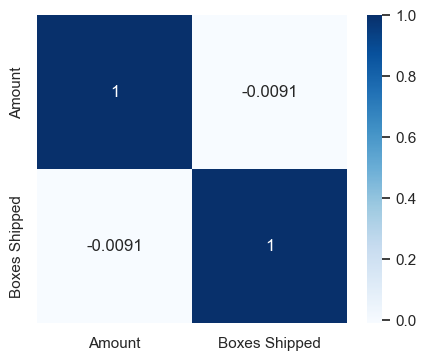

In [31]:
plt.figure(figsize=(5,4))
sns.heatmap(df_clean[['Amount', 'Boxes Shipped']].corr(), annot=True, cmap='Blues')
plt.show()

In [ ]:
The correlation matrix shows the relationship between numerical features. If a strong correlation exists, PCA can be applied.

In [17]:
from sklearn.decomposition import PCA

X = df_clean[['Amount', 'Boxes Shipped']]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(pca.explained_variance_ratio_)

[0.50454018 0.49545982]


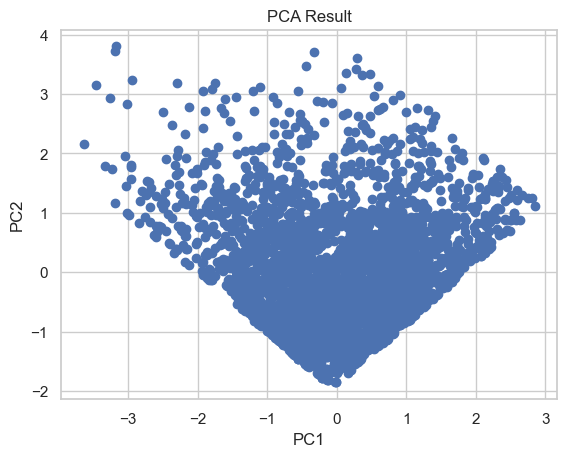

In [18]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Result")
plt.show()

In [ ]:
PCA was applied to reduce dimensionality while preserving most of the variance in the data.